<a href="https://colab.research.google.com/github/varaiitj2527/PRMLProject/blob/main/Model/Clustering_Models/Supervised_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/varaiitj2527/PRMLProject.git
%cd PRMLProject

Cloning into 'PRMLProject'...
remote: Enumerating objects: 118, done.
remote: Counting objects: 100% (100/100), done.
remote: Compressing objects: 100% (89/89), done.
remote: Total 118 (delta 32), reused 21 (delta 2), pack-reused 18 (from 2)
Receiving objects: 100% (118/118), 206.29 MiB | 27.57 MiB/s, done.
Resolving deltas: 100% (32/32), done.
Updating files: 100% (40/40), done.
Filtering content: 100% (14/14), 1.29 GiB | 65.62 MiB/s, done.
Encountered 2 file(s) that should have been pointers, but weren't:
	PreProcessedData/quicknet_test.pkl
	PreProcessedData/quicknet_train.pkl
/content/PRMLProject


In [ ]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [ ]:
def unpickle(filename) :

  with open(filename, 'rb') as file :
      data = pickle.load(file, encoding='bytes')

  return data


In [ ]:
train_RawData = unpickle('PreProcessedData/RawPixels_train.pkl')
test_RawData = unpickle('PreProcessedData/RawPixels_test.pkl')

y_train = unpickle('PreProcessedData/Labels_train.pkl')
y_test = unpickle('PreProcessedData/Labels_test.pkl')

train_PcaData = unpickle('PreProcessedData/TrainFeaturesPCA.pkl')
test_PcaData = unpickle('PreProcessedData/TestFeaturesPCA.pkl')

train_HoGData = unpickle('PreProcessedData/TrainFeaturesHoG.pkl')
test_HoGData = unpickle('PreProcessedData/TestFeaturesHoG.pkl')

train_Pca_HoGData = unpickle('PreProcessedData/TrainFeaturesPCA_HoG.pkl')
test_Pca_HoGData = unpickle('PreProcessedData/TestFeaturesPCA_HoG.pkl')

train_HoG_PcaData = unpickle('PreProcessedData/TrainFeaturesHoG_PCA.pkl')
test_HoG_PcaData = unpickle('PreProcessedData/TestFeaturesHoG_PCA.pkl')

train_ResnetData = unpickle('PreProcessedData/Resnet_train.pkl')
test_ResnetData = unpickle('PreProcessedData/Resnet_test.pkl')

train_QuicknetData = unpickle('quicknet_train.pkl')
test_QuicknetData = unpickle('quicknet_test.pkl')

In [ ]:
def Finding_centriods(X_train, y_train) :

    centriods = []
    for i in range(10):
      centriods.append([])

    for (x, y) in zip(X_train, y_train):
        centriods[y].append(x)

    for i in range(len(centriods)):
        centriods[i] = np.mean(centriods[i], axis=0)

    return centriods


def predict_labels(X_test, centroids) :

  predicted_labels = []
  for x in X_test:
    distances = [np.linalg.norm(x - c) for c in centroids]
    predicted_label = np.argmin(distances)
    predicted_labels.append(predicted_label)

  return predicted_labels

def calculate_accuracy(predicted_labels, y_test) :

  correct_predictions = np.sum(predicted_labels == y_test)
  total_predictions = len(y_test)
  accuracy = correct_predictions / total_predictions

  return accuracy

def Confusion(y_test, y_pred,name) :

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix for ' + name)
    plt.show()

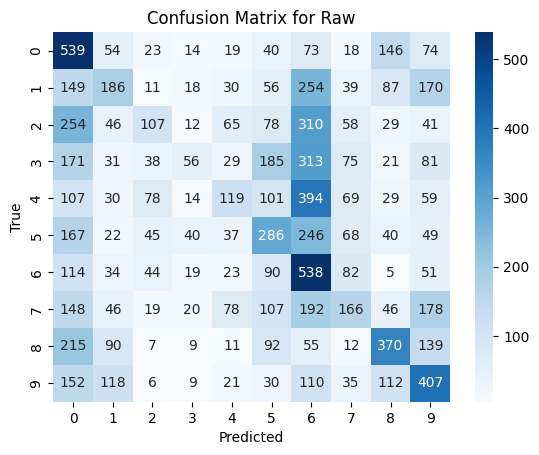

Raw Accuracy : 0.2774


In [ ]:
centriods_Raw = Finding_centriods(train_RawData, y_train)
predicted_labels_Raw = predict_labels(test_RawData, centriods_Raw)
accuracy_Raw = calculate_accuracy(predicted_labels_Raw, y_test)
Confusion(y_test,predicted_labels_Raw,'Raw')
print("Raw Accuracy :", accuracy_Raw)

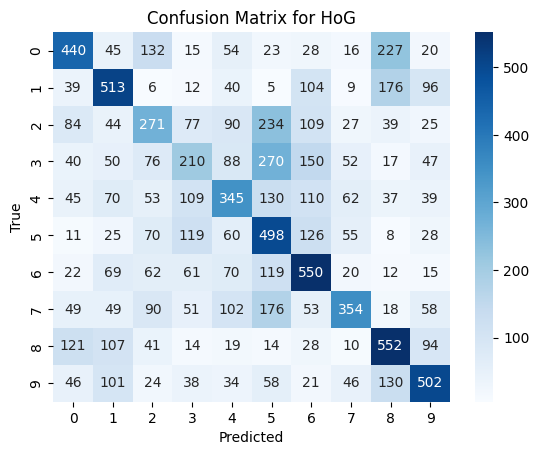

HoG Accuracy : 0.4235


In [ ]:
centriods_HoG = Finding_centriods(train_HoGData, y_train)
predicted_labels_HoG = predict_labels(test_HoGData, centriods_HoG)
accuracy_HoG = calculate_accuracy(predicted_labels_HoG, y_test)
Confusion(y_test,predicted_labels_HoG,'HoG')
print("HoG Accuracy :", accuracy_HoG)

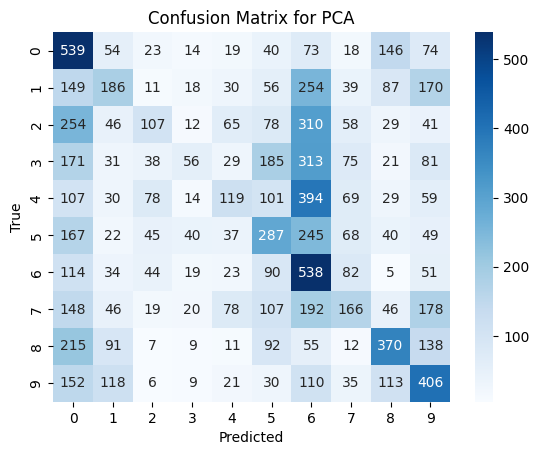

PCA Accuracy : 0.2774


In [ ]:
centriods_Pca = Finding_centriods(train_PcaData, y_train)
predicted_labels_Pca = predict_labels(test_PcaData, centriods_Pca)
accuracy_Pca = calculate_accuracy(predicted_labels_Pca, y_test)
Confusion(y_test,predicted_labels_Pca,'PCA')
print("PCA Accuracy :", accuracy_Pca)

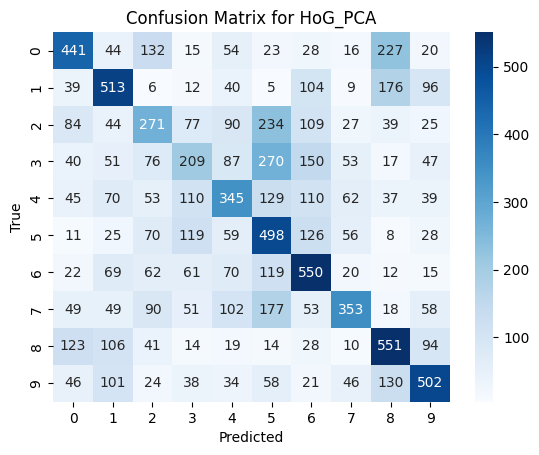

HoG_PCA Accuracy : 0.4233


In [ ]:
centriods_HoG_Pca = Finding_centriods(train_HoG_PcaData, y_train)
predicted_labels_HoG_Pca = predict_labels(test_HoG_PcaData, centriods_HoG_Pca)
accuracy_HoG_Pca = calculate_accuracy(predicted_labels_HoG_Pca, y_test)
Confusion(y_test,predicted_labels_HoG_Pca,'HoG_PCA')
print("HoG_PCA Accuracy :", accuracy_HoG_Pca)

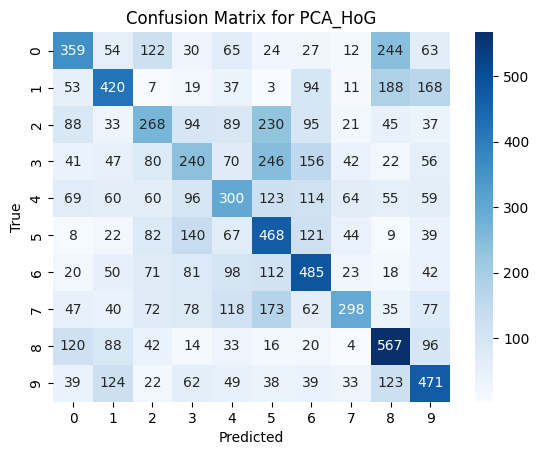

PCA_HoG Accuracy : 0.3876


In [ ]:
centriods_Pca_HoG = Finding_centriods(train_Pca_HoGData, y_train)
predicted_labels_Pca_HoG = predict_labels(test_Pca_HoGData, centriods_Pca_HoG)
accuracy_Pca_HoG = calculate_accuracy(predicted_labels_Pca_HoG, y_test)
Confusion(y_test,predicted_labels_Pca_HoG,'PCA_HoG')
print("PCA_HoG Accuracy :", accuracy_Pca_HoG)

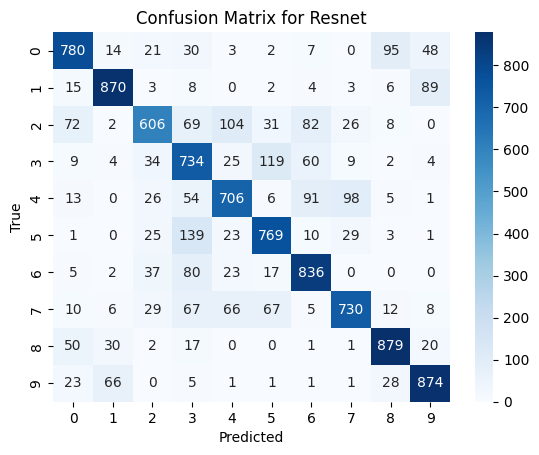

Resnet Accuracy : 0.7784


In [ ]:
centriods_Resnet = Finding_centriods(train_ResnetData, y_train)
predicted_labels_Resnet = predict_labels(test_ResnetData, centriods_Resnet)
accuracy_Resnet = calculate_accuracy(predicted_labels_Resnet, y_test)
Confusion(y_test,predicted_labels_Resnet,'Resnet')
print("Resnet Accuracy :", accuracy_Resnet)

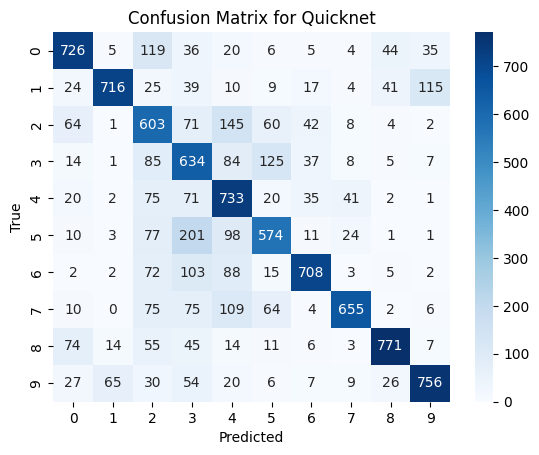

Quicknet Accuracy : 0.6876


In [ ]:
centriods_Quicknet = Finding_centriods(train_QuicknetData, y_train)
predicted_labels_Quicknet = predict_labels(test_QuicknetData, centriods_Quicknet)
accuracy_Quicknet = calculate_accuracy(predicted_labels_Quicknet, y_test)
Confusion(y_test,predicted_labels_Quicknet,'Quicknet')
print("Quicknet Accuracy :", accuracy_Quicknet)